# Validación con VSX + predicción final sobre masivas

Espejo del análisis OGLE (`2_Github_TESS_variability_OGLE.ipynb`) usando como
ground truth el `Period`/`Type` de VSX para las 1152 masivas con contraparte
(`catalogs/1_MassiveXVSX.csv`, ver `1_preparate_data_VSX.ipynb`).

- **`per_vsx`** = período VSX (benchmark). **`per`** = período detectado LS/ACF.
  Nunca se mezclan (misma trampa que `per_ogle`).
- `label=1` ⇔ `per_vsx < 13` d (detectable en un sector TESS); `label=0` ⇔
  `per_vsx ≥ 13` d. Las estrellas sin período quedan aparte.
- El gate de incertidumbre (**`instability`** = σ del BRF entre pasadas
  MC-dropout) se re-valida aquí: en OGLE separó los FP con AUC≈0.86.

Predicciones por peak: `results/brf_mc_vsx_<model>.csv`, generadas con

```
python scripts/run_brf_snr.py --peaks results/peaks_vsx_subset.parquet \
    --model <model> --n-iter 50 --gate-mode none --out results/brf_mc_vsx_<model>.csv
```

Kernel: **CNN_TESS** (el notebook no ejecuta la CNN; solo lee los CSVs).

In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from msv import config

MODELS_EVAL = ["Number_DST", "Number_ELL"]   # candidatos del benchmark OGLE
TOL = config.TOL                             # 5% para match de período
HARMONICS = [1.0, 2.0, 0.5, 3.0, 1/3]
PERIODIC = set(config.PERIODIC)

xm = pd.read_csv(config.CATALOGS_DIR / "1_MassiveXVSX.csv")
xm["per_vsx"] = xm["Period"]
xm["label"] = np.where(xm["per_vsx"] < 13, 1, np.where(xm["per_vsx"] >= 13, 0, np.nan))
print(xm["label"].value_counts(dropna=False).rename({1:"label=1 (P<13d)",0:"label=0 (P>=13d)"}).to_string())

label
NaN                 585
label=1 (P<13d)     528
label=0 (P>=13d)     39


## Mapeo de tipos VSX a las 8 clases del BRF

VSX usa tipos compuestos (`DSCT|GDOR|SXPHE`, `EA/DM`, `DCEP:`): se toma el
token principal, sin flag `:` ni sufijos entre paréntesis. Los tipos de
masivas sin equivalente en las 8 clases (BCEP, ACYG, SPB, BE, GCAS...) quedan
`expected_class=None` — no sirven para chequear la clase, pero **sí** para el
period recovery.

In [ ]:
# El mapeo y el tokenizador viven en msv.review (misma fuente que usa
# scripts/build_vsx_review.py y el revisor visual de más abajo).
from msv.review import TYPE2CLASS_VSX, vsx_main_token

xm["vsx_token"] = xm["Type"].map(vsx_main_token)
xm["expected_class"] = xm["vsx_token"].map(TYPE2CLASS_VSX)

lab1 = xm[xm["label"] == 1]
print(f"label=1: {len(lab1)} | mapeables: {lab1['expected_class'].notna().sum()}")
print(lab1["expected_class"].value_counts().to_string())
print("\nno mapeables top:", lab1[lab1['expected_class'].isna()]['vsx_token'].value_counts().head(6).to_dict())

## Cargar predicciones y anotar con el benchmark

In [3]:
def load_pred(model):
    df = pd.read_csv(config.RESULTS_DIR / f"brf_mc_vsx_{model}.csv")
    df = df.merge(xm[["TIC", "per_vsx", "label", "vsx_token", "expected_class"]],
                  on="TIC", how="left")
    df["is_periodic"] = df["brf_class"].isin(PERIODIC)
    # match de período contra per_vsx con armónicos
    ratio = df["per"].to_numpy()[:, None] / (df["per_vsx"].to_numpy()[:, None] * np.array(HARMONICS)[None, :])
    df["period_match"] = np.abs(ratio - 1).min(axis=1) <= TOL
    return df

preds = {m: load_pred(m) for m in MODELS_EVAL}
for m, df in preds.items():
    print(f"{m}: {len(df)} peaks | {df.groupby(['TIC','sector']).ngroups} pares | "
          f"clases: {df['brf_class'].value_counts().to_dict()}")

Number_DST: 42445 peaks | 3179 pares | clases: {'Rndm': 31405, 'CEP': 3714, 'E': 3090, 'ELL': 1859, 'DST': 1439, 'LPV': 521, 'RR': 395}
Number_ELL: 42445 peaks | 3179 pares | clases: {'Rndm': 32420, 'CEP': 3414, 'E': 2289, 'ELL': 1745, 'DST': 1273, 'LPV': 870, 'RR': 406, 'M': 6}


## Métricas sin gate

- **FP (label=0)**: peaks de estrellas con `per_vsx ≥ 13` d clasificados en
  clase periódica — no deberían existir.
- **Recall (label=1)**: pares (TIC, sector) con al menos un peak periódico
  cuyo período matchea `per_vsx` (±5%, armónicos ×{2,½,3,⅓}).
- **Clase (label=1 mapeables)**: el peak periódico de mayor `brf_prob` con
  match de período vs `expected_class`.

In [4]:
def metrics_base(df):
    out = {}
    l0 = df[df["label"] == 0]
    out["FP_peaks_l0"] = int((l0["is_periodic"]).sum())
    out["peaks_l0"] = len(l0)
    out["FP_rate_l0"] = out["FP_peaks_l0"] / max(len(l0), 1)
    l1 = df[df["label"] == 1]
    by_pair = l1.groupby(["TIC", "sector"]).apply(
        lambda g: bool((g["is_periodic"] & g["period_match"]).any()))
    out["recall_l1"] = by_pair.mean()
    out["pairs_l1"] = len(by_pair)
    # clase correcta entre los mapeables con período recuperado
    ok = l1[l1["is_periodic"] & l1["period_match"] & l1["expected_class"].notna()]
    best = ok.sort_values("brf_prob", ascending=False).groupby("TIC").first()
    out["class_acc_l1"] = float((best["brf_class"] == best["expected_class"]).mean()) if len(best) else np.nan
    out["tics_class_eval"] = len(best)
    return out

base = pd.DataFrame({m: metrics_base(df) for m, df in preds.items()}).T
print(base.to_string())

            FP_peaks_l0  peaks_l0  FP_rate_l0  recall_l1  pairs_l1  class_acc_l1  tics_class_eval
Number_DST        544.0    1446.0    0.376210   0.792426    1426.0      0.653137            271.0
Number_ELL        446.0    1446.0    0.308437   0.776297    1426.0      0.654275            269.0


### Confusión de clases (label=1 mapeables, período recuperado)

In [5]:
for m, df in preds.items():
    l1 = df[(df["label"] == 1) & df["is_periodic"] & df["period_match"]
            & df["expected_class"].notna()]
    best = l1.sort_values("brf_prob", ascending=False).groupby("TIC").first()
    conf = pd.crosstab(best["expected_class"], best["brf_class"])
    print(f"=== {m} (VSX expected -> BRF, {len(best)} TICs) ===")
    print(conf.to_string(), "\n")

=== Number_DST (VSX expected -> BRF, 271 TICs) ===
brf_class       CEP  DST    E  ELL  RR
expected_class                        
CEP              31    0    1    3   0
DST              13    3    3   28   1
E                16    2  133   18   0
ELL               4    0    4   10   0
RR                1    0    0    0   0 

=== Number_ELL (VSX expected -> BRF, 269 TICs) ===
brf_class       CEP  DST    E  ELL
expected_class                    
CEP              31    0    0    4
DST              15    3    3   26
E                16    2  132   18
ELL               4    0    4   10
RR                1    0    0    0 



### Period recovery global (independiente del BRF)

¿Los periodogramas encuentran el período VSX? — por estrella label=1, sin
exigir clase periódica (solo que exista el peak).

In [6]:
df0 = preds[MODELS_EVAL[0]]
l1 = df0[df0["label"] == 1]
by_tic = l1.groupby("TIC")["period_match"].any()
print(f"period recovery (algún peak matchea per_vsx): {by_tic.mean():.1%} de {len(by_tic)} TICs")
rec_by_tok = l1.groupby("vsx_token").apply(
    lambda g: g.groupby("TIC")["period_match"].any().mean()).sort_values()
cnt_by_tok = l1.groupby("vsx_token")["TIC"].nunique()
tab = pd.DataFrame({"recovery": rec_by_tok, "n_TIC": cnt_by_tok}).query("n_TIC >= 5")
print(tab.sort_values("n_TIC", ascending=False).to_string())

period recovery (algún peak matchea per_vsx): 93.0% de 528 TICs
           recovery  n_TIC
vsx_token                 
BCEP       0.933884    121
EA         1.000000     83
DSCT       0.791667     72
VAR        0.840909     44
EB         0.974359     39
E          0.945946     37
DCEP       1.000000     24
ELL        0.947368     19
ACYG       0.916667     12
ESD        1.000000     11
BE         1.000000     10
SPB        0.888889      9
DCEPS      1.000000      7


## Gate de incertidumbre: ¿`instability` separa los FP también aquí?

Positivos = peaks FP (label=0 clasificados periódicos). Negativos = peaks
buenos (label=1, periódicos, con match de período). AUC por Mann-Whitney —
en OGLE dio ≈0.86 para `instability` (el σ de la CNN no separaba).

Number_DST instability: AUC=0.709  (FP=544, OK=2810)
Number_DST sigma_top: AUC=0.590  (FP=544, OK=2810)


Number_ELL instability: AUC=0.700  (FP=446, OK=2636)


Number_ELL sigma_top: AUC=0.608  (FP=446, OK=2636)


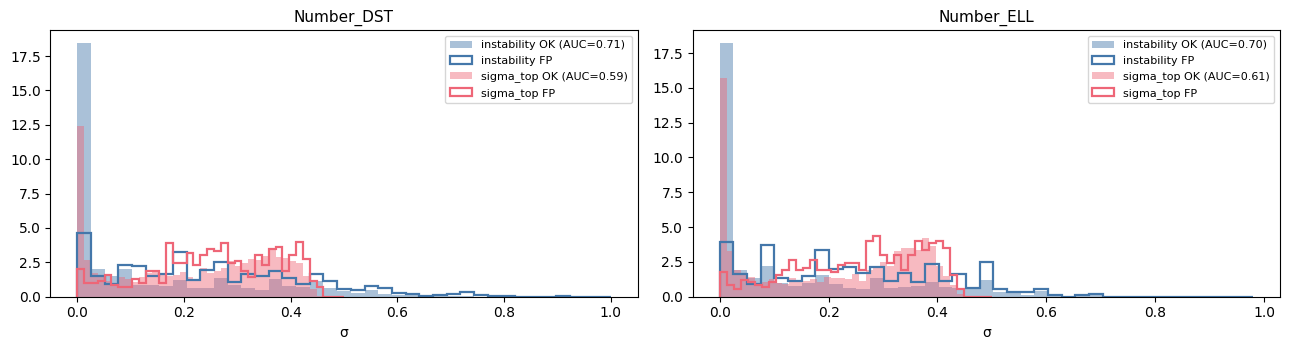

In [7]:
def auc_mw(pos, neg):
    # AUC = P(pos > neg), rank-based (sin sklearn)
    x = np.concatenate([pos, neg]); r = pd.Series(x).rank().to_numpy()
    return (r[:len(pos)].sum() - len(pos) * (len(pos) + 1) / 2) / (len(pos) * len(neg))

fig, axes = plt.subplots(1, len(MODELS_EVAL), figsize=(6.5 * len(MODELS_EVAL), 3.6),
                         squeeze=False)
for ax, (m, df) in zip(axes[0], preds.items()):
    fp = df[(df["label"] == 0) & df["is_periodic"]]
    tp = df[(df["label"] == 1) & df["is_periodic"] & df["period_match"]]
    for col, colr in [("instability", "#4477AA"), ("sigma_top", "#EE6677")]:
        a = auc_mw(fp[col].to_numpy(), tp[col].to_numpy())
        bins = np.linspace(0, max(df[col].max(), 0.5), 40)
        ax.hist(tp[col], bins=bins, density=True, alpha=0.45, color=colr,
                label=f"{col} OK (AUC={a:.2f})")
        ax.hist(fp[col], bins=bins, density=True, histtype="step", lw=1.6,
                color=colr, label=f"{col} FP")
        print(f"{m} {col}: AUC={a:.3f}  (FP={len(fp)}, OK={len(tp)})")
    ax.set_title(m, fontsize=11); ax.set_xlabel("σ"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Barrido de τ (gate `instability`): FP vs recall y elección del corte

     model   tau  FP_gate  FP_frac  recall_gate  recall_frac
Number_DST 0.020       65    0.119        0.567        0.716
Number_DST 0.050       86    0.158        0.609        0.768
Number_DST 0.080      113    0.208        0.642        0.811
Number_DST 0.100      131    0.241        0.655        0.827
Number_DST 0.120      162    0.298        0.666        0.841
Number_DST 0.150      183    0.336        0.675        0.851
Number_DST 0.200      251    0.461        0.698        0.881
Number_DST 0.250      295    0.542        0.715        0.902
Number_DST 0.300      345    0.634        0.737        0.930
Number_ELL 0.020       44    0.099        0.527        0.678
Number_ELL 0.050       62    0.139        0.554        0.714
Number_ELL 0.080       91    0.204        0.595        0.767
Number_ELL 0.100      114    0.256        0.615        0.792
Number_ELL 0.120      129    0.289        0.629        0.810
Number_ELL 0.150      142    0.318        0.639        0.823
Number_ELL 0.200      19

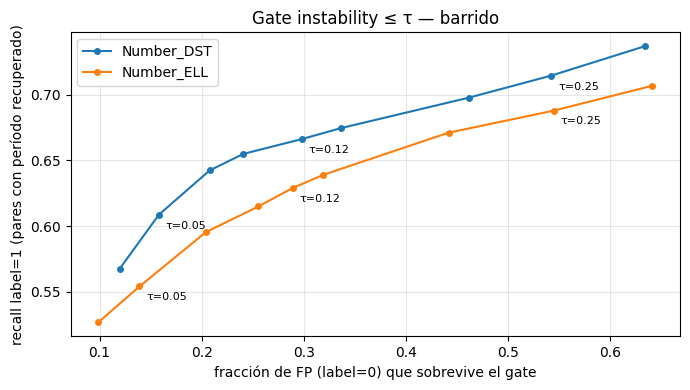


ELEGIDO: Number_DST, gate instability <= 0.12: FP 30% del base, recall 0.666 (84% del base)


In [8]:
rows = []
TAUS = [0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]
for m, df in preds.items():
    nfp = int((df["is_periodic"] & (df["label"] == 0)).sum())
    l1 = df[df["label"] == 1]
    base_rec = l1.groupby(["TIC", "sector"]).apply(
        lambda g: bool((g["is_periodic"] & g["period_match"]).any())).mean()
    for tau in TAUS:
        surv = df["is_periodic"] & (df["instability"] <= tau)
        fp = int((surv & (df["label"] == 0)).sum())
        rec = l1.assign(s=surv[l1.index]).groupby(["TIC", "sector"]).apply(
            lambda g: bool((g["s"] & g["period_match"]).any())).mean()
        rows.append(dict(model=m, tau=tau, FP_gate=fp, FP_frac=fp / nfp,
                         recall_gate=rec, recall_frac=rec / base_rec))
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False, float_format="%.3f"))

fig, ax = plt.subplots(figsize=(7, 4))
for m, g in sweep.groupby("model"):
    ax.plot(g["FP_frac"], g["recall_gate"], "o-", ms=4, label=m)
    for _, r in g.iterrows():
        if r["tau"] in (0.05, 0.12, 0.25):
            ax.annotate(f"τ={r['tau']:.2f}", (r["FP_frac"], r["recall_gate"]),
                        xytext=(5, -10), textcoords="offset points", fontsize=8)
ax.set_xlabel("fracción de FP (label=0) que sobrevive el gate")
ax.set_ylabel("recall label=1 (pares con período recuperado)")
ax.set_title("Gate instability ≤ τ — barrido")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Elección: Number_DST retiene más recall a FP igualado que Number_ELL
# (τ=0.08: FP=113/rec=0.642 vs τ=0.10: FP=114/rec=0.615). τ=0.12 (mismo valor
# que SIGMA_MAX del repo) mata ~70% de los FP conservando ~84% del recall.
MODEL_FINAL, TAU_FINAL = "Number_DST", 0.12
sel = sweep.query("model == @MODEL_FINAL and tau == @TAU_FINAL").iloc[0]
print(f"\nELEGIDO: {MODEL_FINAL}, gate instability <= {TAU_FINAL}: "
      f"FP {sel.FP_frac:.0%} del base, recall {sel.recall_gate:.3f} "
      f"({sel.recall_frac:.0%} del base)")

## Predicción final sobre TODAS las masivas (2c)

Con el modelo y τ elegidos arriba, el run final se lanza (env **CNN_TESS_min**):

```
python scripts/run_brf_snr.py --peaks peaks.parquet --model <ganador> \
    --n-iter 50 --gate-col instability --sigma-max <tau> \
    --gate-mode relabel --out results/brf_mc_peaks_final.csv
```

y la cascada Path-2 (`msv.cascade`) colapsa a una clase por TIC.

In [9]:
FINAL_CSV = config.RESULTS_DIR / "brf_mc_peaks_final.csv"
if not FINAL_CSV.exists():
    print("Aún no existe el run final — lanzar el comando de arriba primero.")
else:
    from msv.cascade import path2_cascade, write_path2_catalogs
    pred_fin = pd.read_csv(FINAL_CSV)
    cat = pd.read_csv(config.CATALOGS_DIR / "3_MassiveXTessV8_LC_DeltaMagnitude_Clean.csv")
    main, tic_class = path2_cascade(pred_fin, cat_tics=cat["TIC"].astype(int).unique())
    write_path2_catalogs(main, config.CATALOGS_DIR, suffix="_final")
    print("clases finales por TIC:")
    print(tic_class.value_counts().to_string())
    print(f"\n-> catalogs/catalog_path2_*_final.csv ({main['TIC'].nunique()} TICs)")

clases finales por TIC:
final_class_tic
Rndm             1083
Unconstrained     916
ELL               803
E                 377
DST               275
Irregular          45
Mixed              40
CEP                38
RR                  1

-> catalogs/catalog_path2_*_final.csv (3578 TICs)


### Sanity check: masivas VSX vs clase final del pipeline

In [10]:
if FINAL_CSV.exists():
    tc = tic_class.rename("final_class_tic").rename_axis("TIC").reset_index()
    chk = tc.merge(xm[["TIC", "vsx_token", "expected_class", "per_vsx", "label"]], on="TIC")
    ok = chk[chk["expected_class"].notna() & (chk["label"] == 1)]
    agree = (ok["final_class_tic"] == ok["expected_class"]).mean()
    print(f"acuerdo clase final vs VSX (label=1 mapeables, n={len(ok)}): {agree:.1%}")
    print(pd.crosstab(ok["expected_class"], ok["final_class_tic"]).to_string())
    l0 = chk[chk["label"] == 0]
    fp_final = l0[~l0["final_class_tic"].isin(["Rndm", "Irregular", "No_periodo", "Unconstrained"])]
    print(f"\nlabel=0 con clase periódica final (FP residual): {len(fp_final)}/{len(l0)}")
    if len(fp_final):
        print(fp_final[["TIC", "vsx_token", "per_vsx", "final_class_tic"]].to_string(index=False))

acuerdo clase final vs VSX (label=1 mapeables, n=307): 52.1%
final_class_tic  CEP  DST    E  ELL  Irregular  Mixed  Rndm  Unconstrained
expected_class                                                            
CEP               20    0    0    2          0      1     1             11
DST                2    4    4   25          1      1    11             24
E                  4    2  126   15          0      0    16             16
ELL                2    0    3   10          0      0     0              4
RR                 0    1    0    0          0      0     1              0

label=0 con clase periódica final (FP residual): 23/39
      TIC vsx_token     per_vsx final_class_tic
 29945178      MISC 2197.000000               E
 55743567       SRD  250.000000               E
108882149      MISC  663.000000               E
138465692        EA   47.615000               E
144356247      MISC  699.000000             ELL
178431738        EA   24.928500               E
209640310       SRD   

# Revisión visual del ground truth VSX

Los `Type`/`Period` de VSX son heterogéneos: vienen de surveys distintos, a
veces heredados de literatura vieja, y para masivas el tipo suele ser un
cajón (`MISC`, `VAR`) o un período orbital que no es el que domina la curva
TESS. **No son ground truth ciego**, así que ninguna métrica de arriba se
puede reportar sin haber mirado las estrellas.

Se revisan a mano las **567** masivas con período en VSX (528 `label=1` +
39 `label=0`) y por cada una se registran tres cosas en
`catalogs/vsx_visual_review.csv`:

| columna | qué significa |
|---|---|
| `vis_verdict` | ¿`per_vsx` pliega bien la curva TESS? `ok` / `maybe` / `bad` / `sin_lc` |
| `vis_shape` | qué se ve realmente al plegar: `EB`, `sinusoidal`, `pulsante`, `multi`, `irregular`, `ruido`, `?` |
| `vis_notes` | texto libre (blends, rampas, sector malo...) |

`vis_verdict` valida el **label** (si el período VSX es malo, la estrella no
sirve como benchmark de period recovery) y `vis_shape` valida el
**`expected_class`** (si VSX dice `EA` pero se ve sinusoidal pura, el
"error" de clase del BRF puede no ser tal).

Preparación (una vez, arma la tabla y cachea las curvas limpias):

```
python scripts/build_vsx_review.py --model Number_DST
```

In [ ]:
from msv import review

# Tabla de revisión: contexto por estrella + veredictos ya marcados (se
# reanuda desde el CSV, nunca pisa lo revisado).
tab_rev = review.build_review_table(xm, preds[MODEL_FINAL])
print(review.review_summary(tab_rev).to_string())

### Revisor interactivo

Tres paneles por estrella: **serie temporal** (color por sector),
**plegada a `per_vsx`** y **plegada al período detectado** (el peak con match
de período o, si no hay, el periódico más probable del BRF). La línea negra
es la mediana en bins de fase — si no hay señal coherente, queda plana.

Botones: **OK / Dudoso / Mal / sin LC** marcan el período **y avanzan solo**;
`forma` y `notas` se aplican a la estrella en pantalla (las notas se guardan
al dar Enter). Todo se escribe en el CSV en cada click, así que se puede
cerrar el notebook y seguir después con `siguiente sin revisar`.

El orden es por prioridad: primero `FP_label0` (39), después `sin_recovery`
(37) y `clase_discrepante` (111) — los tres grupos que pueden cambiar las
conclusiones — y al final `acuerdo` (380), que es control. Para revisar solo
un grupo: `grupos=["FP_label0"]`. Requiere `ipywidgets` (está en el env MSV)
y `%matplotlib inline`.

In [ ]:
%matplotlib inline
lcs = review.load_lc_cache()          # curvas limpias y normalizadas
rev = review.VisualReviewer(tab_rev, lcs).show()   # grupos=[...] para filtrar

### Veredictos → tabla de información

`merge_review` pega `vis_verdict` / `vis_shape` / `vis_notes` a cualquier
tabla con `TIC`. Con eso:

1. **Métricas sobre la muestra limpia**: se recalculan restringiendo a las
   estrellas con `vis_verdict == "ok"`, o sea las que efectivamente son lo
   que decimos que son. La diferencia contra las métricas de arriba es la
   contaminación que metía VSX.
2. **Chequeo de `expected_class`**: `vis_shape` vs el tipo VSX dice cuántas
   discrepancias de clase eran error del BRF y cuántas eran tipo VSX malo.

Mientras la revisión esté incompleta, las celdas corren igual sobre lo ya
marcado (`sin_revisar` queda fuera de la muestra limpia).

In [ ]:
xm_vis = review.merge_review(xm)      # xm + vis_verdict / vis_shape / vis_notes / grupo
print("veredicto por label:")
print(pd.crosstab(xm_vis["label"], xm_vis["vis_verdict"]).to_string())

ok_tics = set(xm_vis.loc[xm_vis["vis_verdict"] == "ok", "TIC"])
if not ok_tics:
    print("\n(todavía no hay estrellas marcadas ok: correr el revisor de arriba)")
else:
    clean = pd.DataFrame({m: metrics_base(df[df["TIC"].isin(ok_tics)])
                          for m, df in preds.items()}).T
    print(f"\nmétricas sobre las {len(ok_tics)} estrellas validadas a ojo:")
    print(clean.to_string())
    print("\n(arriba, sin validar:)")
    print(base.to_string())

In [ ]:
# ¿La morfología vista a ojo respalda el `expected_class` de VSX?
vis = xm_vis[xm_vis["vis_shape"].fillna("").ne("") & xm_vis["expected_class"].notna()]
if vis.empty:
    print("(sin morfologías marcadas todavía)")
else:
    print("forma vista vs tipo VSX:")
    print(pd.crosstab(vis["expected_class"], vis["vis_shape"]).to_string())
    comp = vis.apply(lambda r: review.shape_matches_class(r["vis_shape"],
                                                          r["expected_class"]), axis=1)
    print(f"\ncompatibles con el tipo VSX: {comp.sum():.0f}/{comp.notna().sum():.0f} "
          f"({comp.mean():.1%})")
    mal = vis[comp == False]        # noqa: E712 — VSX dice una cosa, la curva otra
    if len(mal):
        print("\nestrellas donde el tipo VSX no cuadra con lo que se ve:")
        print(mal[["TIC", "Type", "expected_class", "vis_shape", "per_vsx",
                   "vis_notes"]].to_string(index=False))